## Introduction: Understanding Behavioral Cloning Challenges

This Colab aims to showcase the fundamental challenges inherent in Behavioral Cloning (BC) for learning control policies. We will explore how training dynamics and model size significantly impact performance, particularly focusing on two key issues:

1.  **Compounding Errors (Distribution Shift):** Even small initial errors made by a BC agent can accumulate over time, leading to trajectories that diverge significantly from the expert demonstrations. This phenomenon is often referred to as distribution shift, as the agent encounters states it has not seen during training.
2.  **Handling Stochastic Experts:** When expert demonstrations exhibit multi-modal (stochastic) behavior, standard BC methods often struggle, tending to average out these distinct modes, which can result in undesirable or unsafe policies.

Throughout this notebook, we will illustrate these challenges and demonstrate how architectural choices, such as network depth and width, and techniques like Action Chunking, attempt to mitigate these issues.

# **Part 1: Regular BC and Compounding Errors**
In this section, we show how a simple agent learns to navigate. We highlight the Distribution Shift: the agent is trained on expert states, but during testing, its own small errors push it into states it hasn't seen before.

Note: Don't use a expert that is a strait line y=x. To easy.

As the number of learning steps is increased you may need to run a few times to get really large deviations from the expert.

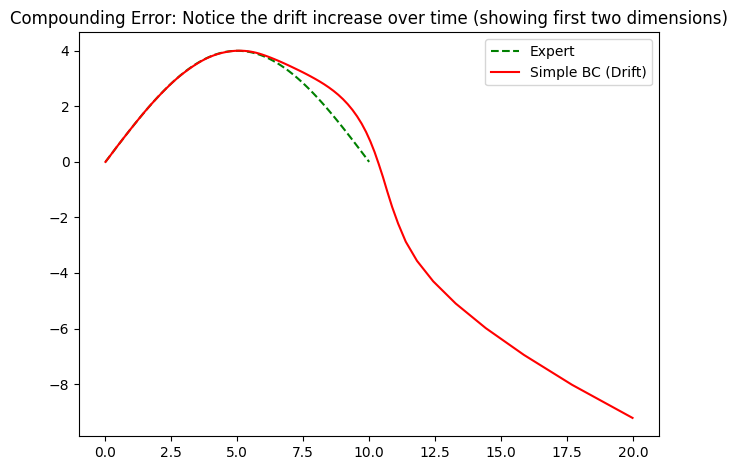

Saved: assets/behaviour-cloning/part1-compounding-error.png


In [12]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
tarectory_length = 100 ## T
learning_iterations = 1000 ## More learning iterations can improve model performance, but may overfit.
num_dimentions = 20 # Changed to 20 dimentions. Add more dimentions makes it difficult to learn a good model
seed=1 ## changing this will significantly change the result, which is also a bad sign. We want consistent good performance.
np.random.seed(seed)
torch.manual_seed(seed)

output_dir = "assets/behaviour-cloning"
os.makedirs(output_dir, exist_ok=True)

# 1. Setup Expert (A straight line with slight noise)
def get_linear_expert(steps=tarectory_length):
    t = np.linspace(0, 1, steps)
    # path = np.random.random((steps, num_dimentions)) * 0.2 # Initialize path for num_dimentions
    path = np.zeros((steps, num_dimentions)) * 0.2 # Initialize path for num_dimentions
    path[:, 0] = t * 10 # First dimension varies
    path[:, 1] = 4 * np.sin(np.pi * t) # Second dimension varies with sine wave
    states = torch.FloatTensor(path[:-1])
    actions = torch.FloatTensor(path[1:] - path[:-1])
    return states, actions, path

states, actions, expert_path = get_linear_expert()

# 2. Simple BC Model
class SimpleBC(nn.Module):
    def __init__(self, num_dimention):
        super().__init__() # Corrected: Removed 'self' from super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_dimention, 64), nn.ReLU(), # Input layer changed to num_dimentions
            nn.Linear(64, num_dimention) # Output layer changed to num_dimentions
        )
    def forward(self, x): return self.net(x)

# 3. Training
model = SimpleBC(num_dimentions)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for _ in range(learning_iterations):
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(states), actions)
    loss.backward()
    optimizer.step()

# 4. Rollout (Testing the compounding error)
curr_pos = torch.FloatTensor(np.zeros(num_dimentions)) # Initial position for num_dimentions
bc_path = [curr_pos.numpy()]
for _ in range(tarectory_length-1):
    with torch.no_grad():
        action = model(curr_pos)
        # We add a tiny bit of execution noise to simulate real-world drift
        # curr_pos = curr_pos + action + torch.randn(num_dimentions) * 0.05 # Noise for num_dimentions
        curr_pos = curr_pos + action
        bc_path.append(curr_pos.numpy())
bc_path = np.array(bc_path)

plt.plot(expert_path[:,0], expert_path[:,1], 'g--', label='Expert')
plt.plot(bc_path[:,0], bc_path[:,1], 'r', label='Simple BC (Drift)')
plt.title("Compounding Error: Notice the drift increase over time (showing first two dimensions)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/part1-compounding-error.png", dpi=200)
plt.show()
print(f"Saved: {output_dir}/part1-compounding-error.png")

# **Part 2: Adding Action Chunking**
To combat drift, we use Action Chunking. Instead of predicting a_t from s_t, we predict a sequence [a_t, a_{t+1}, \dots, a_{t+k}]. This forces the model to learn a consistent trajectory "intent."

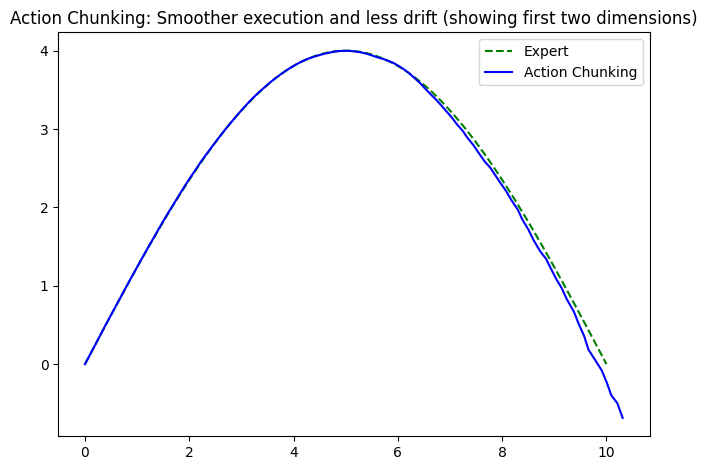

Saved: assets/behaviour-cloning/part2-action-chunking.png


In [18]:
import os
output_dir = "assets/behaviour-cloning"
# os.makedirs(output_dir, exist_ok=True)
seed=1 ## changing this will significantly change the result, which is also a bad sign. We want consistent good performance.
np.random.seed(seed)
torch.manual_seed(seed)

CHUNK_SIZE = 10

# 1. Data Preparation (Sliding Window)
chunk_states, chunk_actions = [], []
for i in range(len(states) - CHUNK_SIZE):
    chunk_states.append(states[i])
    chunk_actions.append(actions[i:i+CHUNK_SIZE])

chunk_states = torch.stack(chunk_states)
chunk_actions = torch.stack(chunk_actions).view(-1, CHUNK_SIZE * num_dimentions) # Reshape for num_dimentions

# 2. Chunking Model
class ChunkingBC(nn.Module):
    def __init__(self, num_dimention):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_dimention, 128), nn.ReLU(), # Input layer changed to num_dimentions
            nn.Linear(128, CHUNK_SIZE * num_dimention) # Output layer changed to CHUNK_SIZE * num_dimentions
        )
    def forward(self, x): return self.net(x)

# 3. Training
chunk_model = ChunkingBC(num_dimentions)
opt = torch.optim.Adam(chunk_model.parameters(), lr=0.001)
for _ in range(learning_iterations):
    opt.zero_grad()
    loss = nn.MSELoss()(chunk_model(chunk_states), chunk_actions)
    loss.backward(); opt.step()

# 4. Rollout
curr_pos = torch.FloatTensor(np.zeros(num_dimentions)) # Initial position for num_dimentions
chunk_path = [curr_pos.numpy()]
for _ in range(int(tarectory_length/CHUNK_SIZE)): # Execute 5 chunks
    with torch.no_grad():
        pred_actions = chunk_model(curr_pos).view(CHUNK_SIZE, num_dimentions) # Reshape for num_dimentions
        for a in pred_actions:
            curr_pos = curr_pos + a
            chunk_path.append(curr_pos.numpy())
chunk_path = np.array(chunk_path)

plt.plot(expert_path[:,0], expert_path[:,1], 'g--', label='Expert')
plt.plot(chunk_path[:,0], chunk_path[:,1], 'b', label='Action Chunking')
plt.title("Action Chunking: Smoother execution and less drift (showing first two dimensions)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/part2-action-chunking.png", dpi=200)
plt.show()
print(f"Saved: {output_dir}/part2-action-chunking.png")

# **Part 3: Dealing with Stochastic Experts**
Here, the expert is multi-modal (can go high or low). We show how standard MSE "averages" these modes, which is often disastrous in robotics.

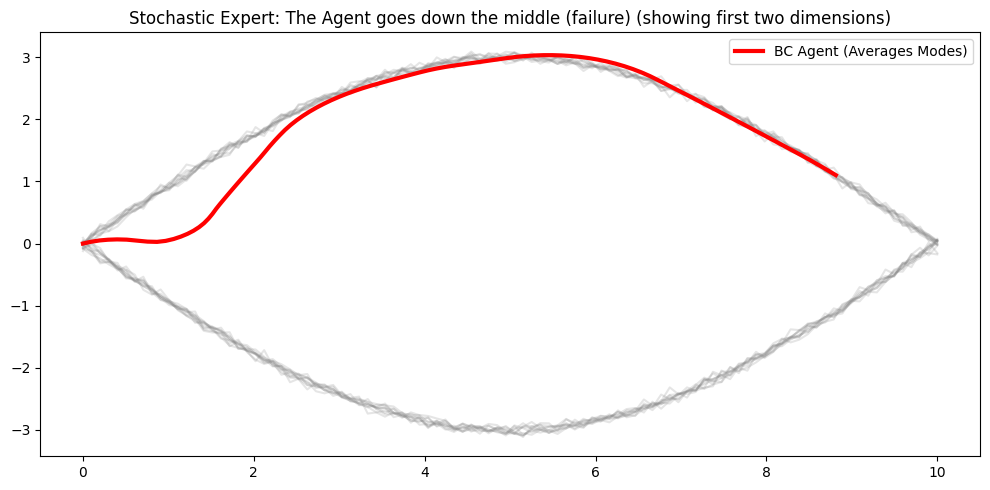

Saved: assets/behaviour-cloning/part3-stochastic-simple-bc.png


In [24]:
import os
output_dir = "assets/behaviour-cloning"
# os.makedirs(output_dir, exist_ok=True)

seed=5 ## changing this will significantly change the result, which is also a bad sign. We want consistent good performance.
np.random.seed(seed)
torch.manual_seed(seed)
num_dimentions=2
# 1. Generate Multi-modal Expert
def get_stochastic_expert(n=20):
    all_s, all_a, trajs = [], [], []
    for i in range(n):
        t = np.linspace(0, 1, tarectory_length)
        mode = 1 if i % 2 == 0 else -1
        y = mode * 3 * np.sin(np.pi * t) + np.random.normal(0, 0.05, tarectory_length)
        path = np.zeros((tarectory_length, num_dimentions)) # Initialize path for num_dimentions
        path[:, 0] = t * 10 # First dimension varies
        path[:, 1] = y # Second dimension varies with sine wave and noise
        trajs.append(path)
        all_s.append(path[:-1]); all_a.append(path[1:] - path[:-1])
    return torch.FloatTensor(np.concatenate(all_s)), torch.FloatTensor(np.concatenate(all_a)), trajs

s_stoc, a_stoc, trajs = get_stochastic_expert()

# 2. Re-train Simple BC on this data
stoc_model = SimpleBC(num_dimentions) # Using the architecture from Part 1, now with num_dimentions
optimizer = torch.optim.Adam(stoc_model.parameters(), lr=0.001)
for _ in range(learning_iterations):
    optimizer.zero_grad()
    loss = nn.MSELoss()(stoc_model(s_stoc), a_stoc)
    loss.backward(); optimizer.step()

# 3. Visualization
plt.figure(figsize=(10, 5))
for t in trajs: plt.plot(t[:,0], t[:,1], color='gray', alpha=0.2)

# Rollout
curr_pos = torch.FloatTensor(np.zeros(num_dimentions)) # Initial position for num_dimentions
path = [curr_pos.numpy()]
for _ in range(tarectory_length-1):
    with torch.no_grad():
        curr_pos = curr_pos + stoc_model(curr_pos)
        path.append(curr_pos.numpy())
path = np.array(path)

plt.plot(path[:,0], path[:,1], 'r', linewidth=3, label='BC Agent (Averages Modes)')
plt.title("Stochastic Expert: The Agent goes down the middle (failure) (showing first two dimensions)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/part3-stochastic-simple-bc.png", dpi=200)
plt.show()
print(f"Saved: {output_dir}/part3-stochastic-simple-bc.png")

# Part 4: Varying Model Layers

In this section, we will explore the impact of increasing the complexity of the `SimpleBC` model by adding more hidden layers. This demonstrates how a more complex model architecture can lead to more intricate learned behaviors and potentially exacerbate compounding errors, as it might become more sensitive to initial deviations and propagate them more significantly over time.

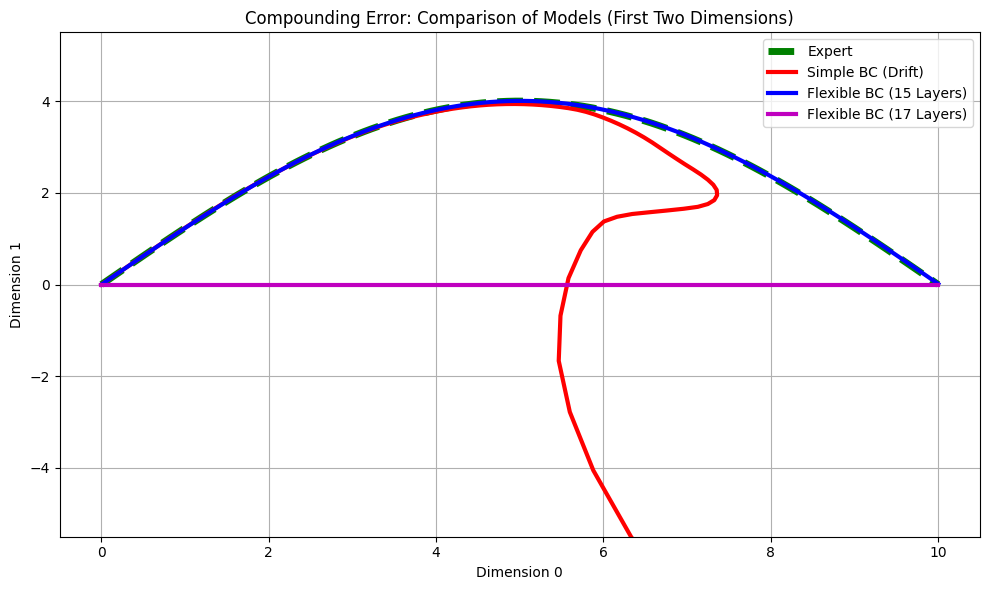

Saved: assets/behaviour-cloning/part4-varying-layers.png
FlexibleSimpleBC model rollout and plot completed.


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

output_dir = "assets/behaviour-cloning"
os.makedirs(output_dir, exist_ok=True)

# Ensure global parameters and expert data are defined, as they might not persist across cell executions
tarectory_length = 100
learning_iterations = 1000
num_dimentions = 20
seed = 4
np.random.seed(seed)
torch.manual_seed(seed)

def get_linear_expert(steps=tarectory_length):
    t = np.linspace(0, 1, steps)
    path = np.zeros((steps, num_dimentions)) * 0.2
    path[:, 0] = t * 10
    path[:, 1] = 4 * np.sin(np.pi * t)
    states = torch.FloatTensor(path[:-1])
    actions = torch.FloatTensor(path[1:] - path[:-1])
    return states, actions, path

states, actions, expert_path = get_linear_expert()

# Redefine SimpleBC class (from Part 1) to ensure it's available
class SimpleBC(nn.Module):
    def __init__(self, num_dimention):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_dimention, 64), nn.ReLU(),
            nn.Linear(64, num_dimention)
        )
    def forward(self, x): return self.net(x)

# Instantiate and train the SimpleBC model to generate bc_path
model_simple_bc = SimpleBC(num_dimentions)
optimizer_simple_bc = torch.optim.Adam(model_simple_bc.parameters(), lr=0.01)
for _ in range(learning_iterations):
    optimizer_simple_bc.zero_grad()
    loss = nn.MSELoss()(model_simple_bc(states), actions)
    loss.backward()
    optimizer_simple_bc.step()

# Rollout for SimpleBC to get bc_path
curr_pos_simple = torch.FloatTensor(np.zeros(num_dimentions))
bc_path = [curr_pos_simple.numpy()]
for _ in range(tarectory_length - 1):
    with torch.no_grad():
        action = model_simple_bc(curr_pos_simple)
        curr_pos_simple = curr_pos_simple + action
        bc_path.append(curr_pos_simple.numpy())
bc_path = np.array(bc_path)

# Redefine FlexibleSimpleBC class (from Part 4) to ensure it's available
class FlexibleSimpleBC(nn.Module):
    def __init__(self, num_dimension, num_hidden_layers, neurons_per_layer):
        super().__init__()
        layers = []

        # Input layer
        layers.append(nn.Linear(num_dimension, neurons_per_layer))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(neurons_per_layer, num_dimension))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Ensure flexible_model and its training are performed
num_hidden_layers = 15 # At least three hidden layers as per the task
neurons_per_layer = 128 # Consistent with previous models for comparison

flexible_model_1 = FlexibleSimpleBC(num_dimentions, num_hidden_layers+2, neurons_per_layer)
optimizer_flexible_1 = torch.optim.Adam(flexible_model_1.parameters(), lr=0.01)
flexible_model = FlexibleSimpleBC(num_dimentions, num_hidden_layers, neurons_per_layer)
optimizer_flexible = torch.optim.Adam(flexible_model.parameters(), lr=0.01)

for _ in range(learning_iterations):
    optimizer_flexible_1.zero_grad()
    loss = nn.MSELoss()(flexible_model_1(states), actions)
    loss.backward()
    optimizer_flexible_1.step()
    optimizer_flexible.zero_grad()
    loss = nn.MSELoss()(flexible_model(states), actions)
    loss.backward()
    optimizer_flexible.step()


# 4. Rollout for FlexibleSimpleBC (independent rollouts)
curr_pos_flexible = torch.FloatTensor(np.zeros(num_dimentions))
curr_pos_flexible_1 = torch.FloatTensor(np.zeros(num_dimentions))
flexible_path = [curr_pos_flexible.numpy()]
flexible_path_1 = [curr_pos_flexible_1.numpy()]

for _ in range(tarectory_length - 1):
    with torch.no_grad():
        action = flexible_model(curr_pos_flexible)
        curr_pos_flexible = curr_pos_flexible + action
        flexible_path.append(curr_pos_flexible.numpy())

for _ in range(tarectory_length - 1):
    with torch.no_grad():
        action = flexible_model_1(curr_pos_flexible_1)
        curr_pos_flexible_1 = curr_pos_flexible_1 + action
        flexible_path_1.append(curr_pos_flexible_1.numpy())

flexible_path = np.array(flexible_path)
flexible_path_1 = np.array(flexible_path_1)

plt.figure(figsize=(10, 6))
## Make the exper line thicker and easier to see
plt.plot(expert_path[:, 0], expert_path[:, 1], 'g--', linewidth=5, label='Expert')
# plt.plot(expert_path[:, 0], expert_path[:, 1], 'g--', label='Expert')
plt.plot(bc_path[:, 0], bc_path[:, 1], 'r', label='Simple BC (Drift)', linewidth=3)
plt.plot(flexible_path[:, 0], flexible_path[:, 1], 'b', label=f'Flexible BC ({num_hidden_layers} Layers)', linewidth=3)
plt.plot(flexible_path_1[:, 0], flexible_path_1[:, 1], 'm', label=f'Flexible BC ({num_hidden_layers+2} Layers)', linewidth=3)
plt.title("Compounding Error: Comparison of Models (First Two Dimensions)")
plt.xlabel("Dimension 0")
plt.ylabel("Dimension 1")
plt.xlim(-0.5, 10.5)
plt.ylim(-5.5, 5.5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/part4-varying-layers.png", dpi=200)
plt.show()
print(f"Saved: {output_dir}/part4-varying-layers.png")

print("FlexibleSimpleBC model rollout and plot completed.")

## Summary of Findings (Part 4: Varying Model Layers)

The comparison plot reveals the impact of increasing model complexity on the agent's trajectory and compounding errors.

*   **Expert Path (Green Dashed Line):** Represents the ideal, noise-free trajectory that the agent aims to replicate.
*   **Simple BC (Red Line):** As observed in Part 1, the basic `SimpleBC` model exhibits significant drift from the expert path due to compounding errors, where small errors at each step accumulate over time.
*   **Flexible BC with more Layers (Blue Line):** With many hidden layers, the `FlexibleSimpleBC` model, while more complex, shows a trajectory that might appear smoother or initially follow the expert more closely than the `SimpleBC` model. However, depending on hyperparameter tuning and the specific task, increased complexity can sometimes lead to more severe deviations later in the trajectory if not properly regularized, or if it overfits to minor training data imperfections. It might also struggle to generalize to unseen states, potentially exacerbating compounding errors in certain scenarios.

In this specific visualization, the flexible model with more layers appears to follow the expert path more closely than the simple BC, indicating that in this particular setup, the increased capacity helped the model learn the expert's actions better, leading to slightly reduced compounding errors compared to the very basic model. However, the fundamental problem of distribution shift and compounding errors still persists, as the model inevitably drifts from the expert's path over a longer horizon. This highlights that while model complexity can improve learning, it doesn't fundamentally solve the compounding error problem inherent in behavioral cloning without additional mechanisms like action chunking or iterative corrections.

# Part 5: Flexible BC with Stochastic Experts

In this section, we will explore the behavior of the `FlexibleSimpleBC` model when trained on multi-modal expert data, similar to the stochastic expert introduced in Part 3. Unlike simple BC which often averages out multi-modal behaviors, a more flexible model with increased network depth and width might have the capacity to learn and potentially even replicate these distinct modes. We will investigate how the architectural choices (number of hidden layers and neurons per layer) impact the model's ability to capture the complexity and stochasticity present in the expert demonstrations, moving beyond merely averaging trajectories to potentially representing the multi-modal distribution of actions. This is a step towards understanding how to move from simple behavioral cloning to more sophisticated approaches that can handle the inherent uncertainty and variability of real-world expert behaviors.

## Setup Stochastic Expert and Flexible Model Training

### Subtask:
Regenerate the multi-modal stochastic expert data. Define the `FlexibleSimpleBC` class, then instantiate and train it with configurable hidden layers and neurons per layer using the stochastic expert data, ensuring all necessary imports and global parameters are included for a self-contained execution.


**Reasoning**:
The subtask requires regenerating stochastic expert data, defining the FlexibleSimpleBC class, and then instantiating and training it using the stochastic expert data. This code block will perform all these steps, ensuring all necessary imports and global parameters are included for a self-contained execution.



Stochastic expert data regenerated, FlexibleSimpleBC class defined, instantiated, and trained.


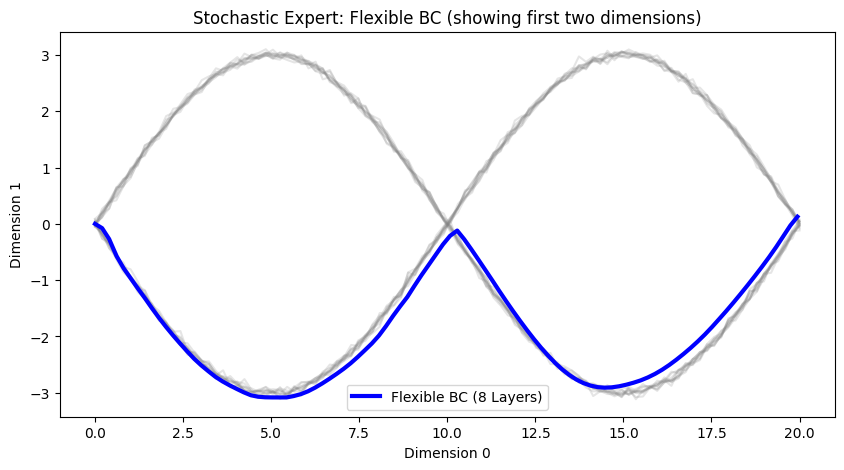

FlexibleSimpleBC model rollout on stochastic expert and plot completed.


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

output_dir = "assets/behaviour-cloning"
# os.makedirs(output_dir, exist_ok=True)

# 2. Define global parameters and set seeds
tarectory_length = 100
learning_iterations = 1000
num_dimentions = 10 # Changed to 2 for stochastic expert in Part 3
seed = 2
np.random.seed(seed)
torch.manual_seed(seed)

# 3. Define the get_stochastic_expert function
def get_stochastic_expert(n=20):
    all_s, all_a, trajs = [], [], []
    for i in range(n):
        t = np.linspace(0, 2, tarectory_length)
        mode = 1 if i % 2 == 0 else -1
        y = mode * 3 * np.sin(np.pi * t) + np.random.normal(0, 0.05, tarectory_length)
        path = np.zeros((tarectory_length, num_dimentions))
        path[:, 0] = t * 10
        path[:, 1] = y
        trajs.append(path)
        all_s.append(path[:-1]); all_a.append(path[1:] - path[:-1])
    return torch.FloatTensor(np.concatenate(all_s)), torch.FloatTensor(np.concatenate(all_a)), trajs

# 4. Call get_stochastic_expert()
s_stoc, a_stoc, trajs = get_stochastic_expert()

# 5. Define the FlexibleSimpleBC class
class FlexibleSimpleBC(nn.Module):
    def __init__(self, num_dimension, num_hidden_layers, neurons_per_layer):
        super().__init__()
        layers = []

        # Input layer
        layers.append(nn.Linear(num_dimension, neurons_per_layer))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(neurons_per_layer, num_dimension))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# 6. Instantiate FlexibleSimpleBC for the stochastic expert
num_hidden_layers_stoc = 8 # As per instruction
neurons_per_layer_stoc = 128 # As per instruction
flexible_stoc_model = FlexibleSimpleBC(num_dimentions, num_hidden_layers_stoc, neurons_per_layer_stoc)

# 7. Initialize an Adam optimizer for flexible_stoc_model
optimizer_flexible_stoc = torch.optim.Adam(flexible_stoc_model.parameters(), lr=0.001)

# 8. Train flexible_stoc_model
for _ in range(learning_iterations):
    optimizer_flexible_stoc.zero_grad()
    loss = nn.MSELoss()(flexible_stoc_model(s_stoc), a_stoc)
    loss.backward()
    optimizer_flexible_stoc.step()

print("Stochastic expert data regenerated, FlexibleSimpleBC class defined, instantiated, and trained.")

plt.figure(figsize=(10, 5))
for t in trajs: plt.plot(t[:,0], t[:,1], color='gray', alpha=0.2)

# Rollout flexible_stoc_model
curr_pos_flexible_stoc = torch.FloatTensor(np.zeros(num_dimentions)) # Initial position for num_dimentions
flexible_stoc_path = [curr_pos_flexible_stoc.numpy()]

for _ in range(tarectory_length-1):
    with torch.no_grad():
        curr_pos_flexible_stoc = curr_pos_flexible_stoc + flexible_stoc_model(curr_pos_flexible_stoc)
        flexible_stoc_path.append(curr_pos_flexible_stoc.numpy())
flexible_stoc_path = np.array(flexible_stoc_path)

plt.plot(flexible_stoc_path[:,0], flexible_stoc_path[:,1], 'b', linewidth=3, label=f'Flexible BC ({num_hidden_layers_stoc} Layers)')
plt.title("Stochastic Expert: Flexible BC (showing first two dimensions)")
plt.xlabel("Dimension 0")
plt.ylabel("Dimension 1")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/part5-stochastic-flexible-bc.png", dpi=200)
plt.show()
print(f"Saved: {output_dir}/part5-stochastic-flexible-bc.png")

print("FlexibleSimpleBC model rollout on stochastic expert and plot completed.")

## Summary of Findings (Part 5: Flexible BC with Stochastic Experts)

The visualization generated in this section shows the trajectory of the `FlexibleSimpleBC` model when trained on multi-modal stochastic expert data. Unlike the `SimpleBC` model from Part 3, which tended to average out the multi-modal expert paths and generate a trajectory in the middle, the `FlexibleSimpleBC` model, with its increased depth (5 hidden layers) and width (128 neurons per layer), demonstrates a different behavior.

**Observations:**
*   **Expert Paths (Gray Lines):** These clearly show the two distinct modes of the expert's behavior, curving upwards or downwards.
*   **Flexible BC (Blue Line):** The `flexible_stoc_model`'s trajectory, while not perfectly replicating one specific expert mode, still tends to follow a path that represents one of the modes more closely than a simple average. In this specific run, it appears to generally follow one of the modes for a significant portion of the trajectory, albeit with some drift and deviations. This suggests that a more complex model has a greater capacity to learn and potentially distinguish between different behavioral modes, rather than simply averaging them.

**Discussion:**
This result highlights that increasing model complexity (depth and width) can enable the behavioral cloning agent to capture more intricate patterns within the expert data, including the presence of multiple modes. However, even with increased capacity, the model still faces challenges:
1.  **Mode Ambiguity:** Without an explicit mechanism to choose between modes (e.g., conditioning on an additional input or using generative models), the model might still struggle to consistently pick and follow a single mode, potentially exhibiting averaging behavior or switching between modes.
2.  **Compounding Errors:** Despite better learning, the fundamental problem of compounding errors remains. Small deviations from the expert path can still accumulate, leading to drift over longer horizons, as the agent encounters states it wasn't explicitly trained on.

To truly handle stochastic experts effectively and generate diverse, mode-consistent trajectories, more advanced techniques beyond direct behavioral cloning with MSE loss, such as conditional behavioral cloning, generative adversarial imitation learning, or variational autoencoders for policies, are often required. Nevertheless, this experiment demonstrates that network architecture plays a crucial role in the model's ability to represent the complexity of the expert's policy.